## 가격을 결정하는 요인이 무엇일까?

최대한 변수를 통제하고 그 원인을 분석해본다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 불러오기
df = pd.read_csv('data/서울시 부동산 실거래가 정보.csv', low_memory=False, encoding='cp949')
df['단위가격'] = df['물건금액(만원)'] / df['건물면적(㎡)']

In [2]:
df.columns

Index(['접수연도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분', '지번구분명', '본번', '부번',
       '건물명', '계약일', '물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)', '층', '권리구분', '취소일',
       '건축년도', '건물용도', '신고구분', '신고한 개업공인중개사 시군구명', '단위가격'],
      dtype='str')

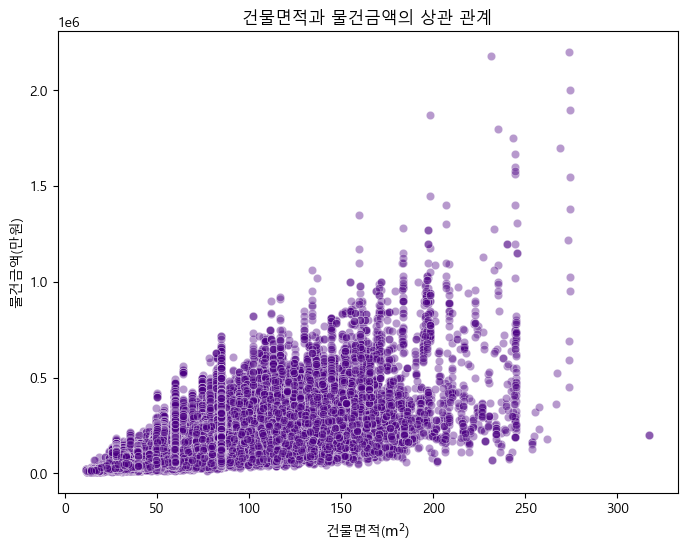

In [3]:
# 3.5.1 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='건물면적(㎡)', y='물건금액(만원)', alpha=0.4, color='indigo')
plt.title('건물면적과 물건금액의 상관 관계')
plt.xlabel('건물면적($\\text{m}^2$)')
plt.ylabel('물건금액(만원)')

plt.show()

### 변수 통제
1. 취소된 거래 제외
2. '분양권' 거래 제외
3. '중개거래' 제외
4. '노원구'에 한정
5. 계약일은 2025년도
6. 건물면적은 85㎡ 기준

In [4]:
df = df[df['취소일'].isna()]
df = df[df['권리구분'] != '분양권']
df = df[df['신고구분'] == '중개거래']
df = df[df['계약일'].between(20250101, 20260101)]  # 2025년 거래 자료
df = df[df['건물면적(㎡)'].between(84, 89)]
df1 = df[df['자치구명'] == '노원구']
print(len(df1))

1024


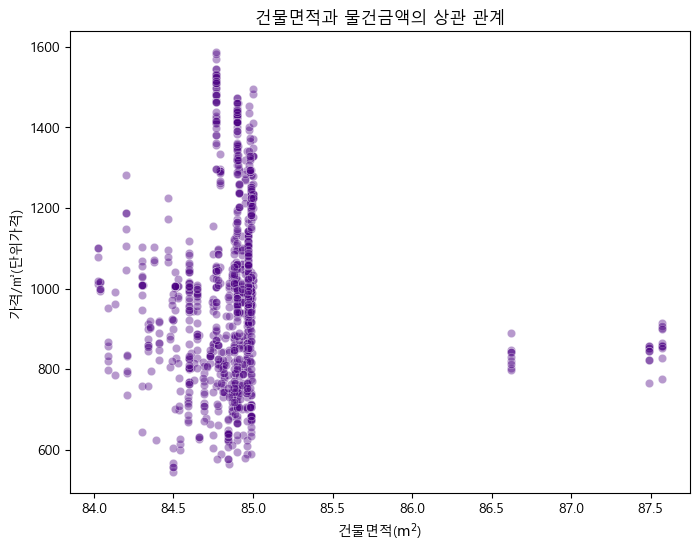

In [5]:
# 3.5.1 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df1, x='건물면적(㎡)', y='단위가격', alpha=0.4, color='indigo')
plt.title('건물면적과 물건금액의 상관 관계')
plt.xlabel('건물면적($\\text{m}^2$)')
plt.ylabel('가격/㎡(단위가격)')

plt.show()

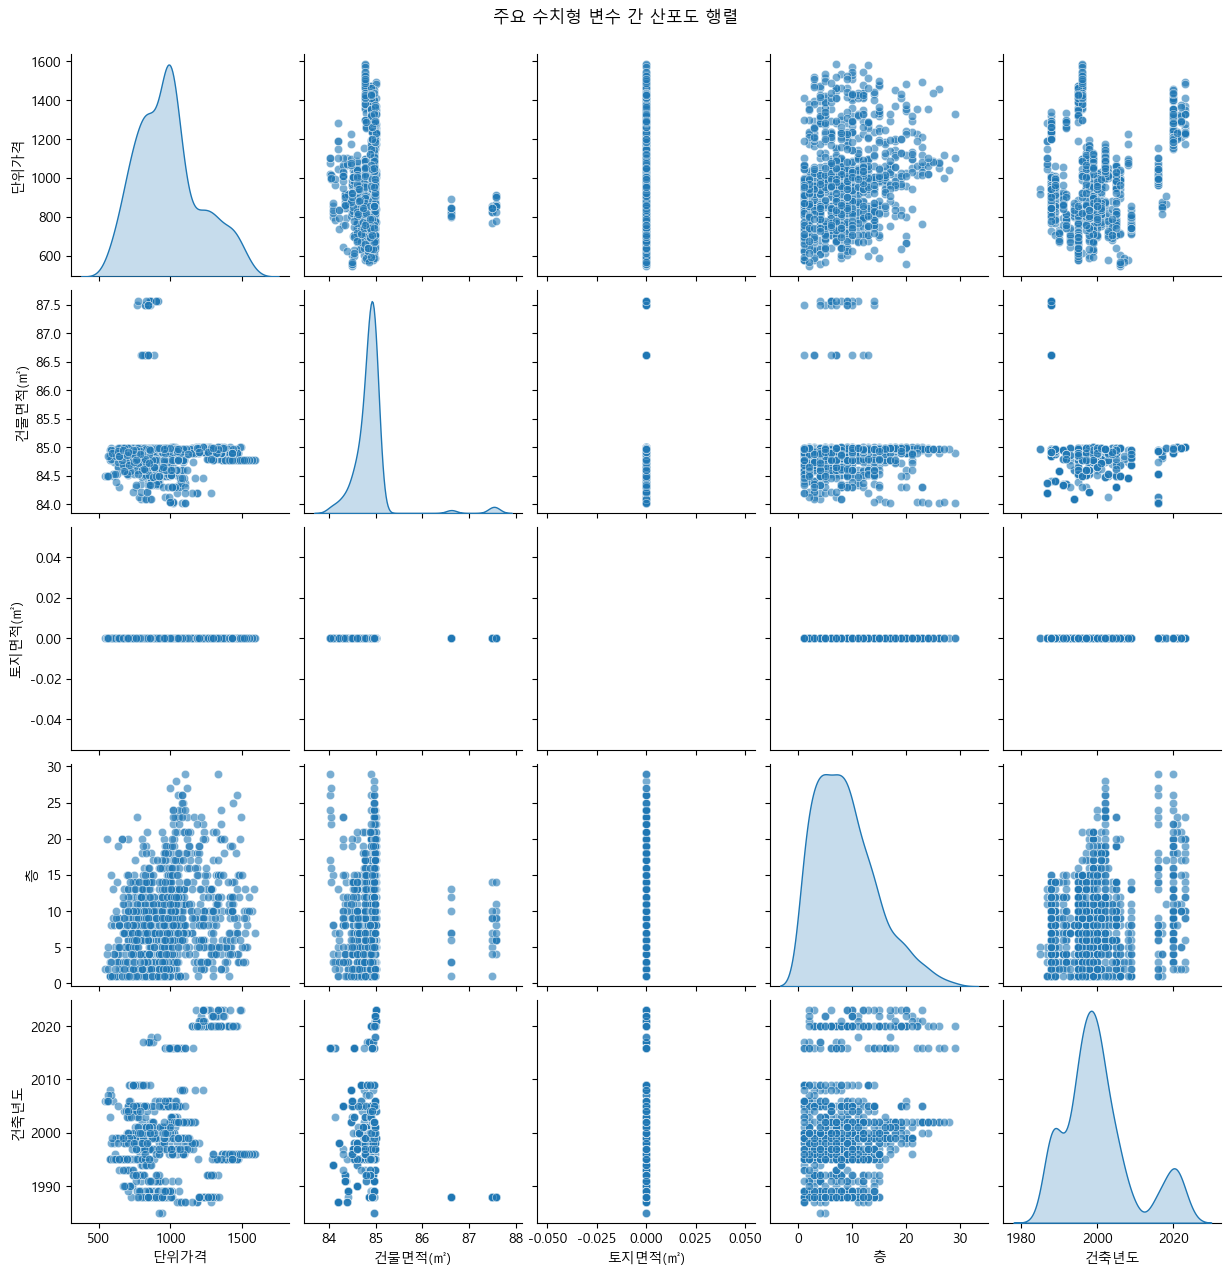

In [6]:
# 3.5.4 주요 변수 산포도 행렬 시각화
selected_cols = ['단위가격', '건물면적(㎡)', '토지면적(㎡)', '층', '건축년도']

df_sample = df1[selected_cols].sample(n=1000, random_state=42)

sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('주요 수치형 변수 간 산포도 행렬', y=1.02)

plt.show()

* 단위가격과 관련있는 변수 없음.
* 아파트 단지별 `df['건물명']` 가격을 비교해봐야 하겠음


In [7]:
df1['건물명'].value_counts()

건물명
한진한화그랑빌       59
청구3           43
월계센트럴아이파크     35
건영3           35
포레나노원         28
              ..
대동             1
길성그랑프리텔아파트     1
중앙하이츠(5지역)     1
서일이츠뷰          1
정진아트리움         1
Name: count, Length: 139, dtype: int64

In [8]:
df1['건물명'].value_counts().head(20)

건물명
한진한화그랑빌       59
청구3           43
월계센트럴아이파크     35
건영3           35
포레나노원         28
하계2현대         26
풍림아파트A        25
한화꿈에그린        24
현대            23
하계1청구         23
학여울청구         20
노원롯데캐슬시그니처    18
한양            18
동아불암          16
한신4차          16
수락리버시티3단지     14
풍림아이원         14
화랑타운아파트       14
청구            13
롯데캐슬루나        13
Name: count, dtype: int64

In [9]:
N = 20

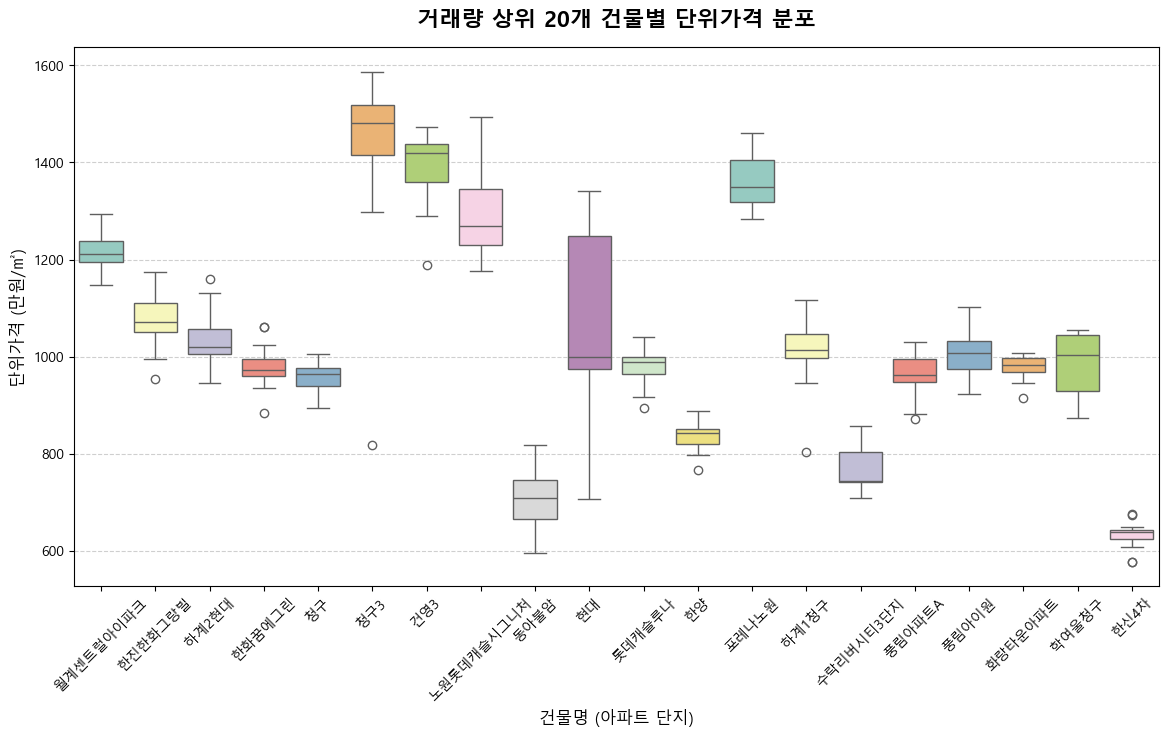

In [10]:
# 거래 건수가 많은 상위 N개 건물명 추출
# (전체 건물을 그리면 그래프가 복잡해지므로 주요 단지만 선별합니다)
top10_buildings = df1['건물명'].value_counts().head(N).index
df_topN = df1[df1['건물명'].isin(top10_buildings)]

# 3. 박스 플롯 시각화
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_topN, 
    x='건물명', 
    y='단위가격', 
    hue='건물명',          # 최신 버전 경고 방지를 위해 hue 지정
    palette='Set3', 
    legend=False          # 범례 숨김
)

# 그래프 장식
plt.title(f'거래량 상위 {N}개 건물별 단위가격 분포', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('건물명 (아파트 단지)', fontsize=12)
plt.ylabel('단위가격 (만원/㎡)', fontsize=12)
plt.xticks(rotation=45)  # 건물명이 길 경우 겹치지 않게 회전
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

가설: 단지별 가격 차이가 있다

건물명 별 단위가격 이상치 제거

In [11]:
# 1. 이상치 판단 함수 정의
def remove_series_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series >= lower_bound) & (series <= upper_bound)

# 2. 그룹별 함수 적용 (멀티인덱스 형태로 결과 반환됨)
valid_mask = df_topN.groupby('건물명')['단위가격'].apply(remove_series_outliers, include_groups=False)

# 3. 중요: 상위 레벨 인덱스(건물명)를 제거하고, 원본 df와 일치하도록 인덱스 순서를 정렬합니다.
valid_mask = valid_mask.reset_index(level=0, drop=True).sort_index()

# 4. 경고 없이 깔끔하게 필터링 수행
df_filtered_outliers = df_topN[valid_mask]

# 5. 결과 확인
print("이상치 제거 전 전체 거래 건수:", len(df_topN))
print("이상치 제거 후 최종 거래 건수:", len(df_filtered_outliers))

이상치 제거 전 전체 거래 건수: 477
이상치 제거 후 최종 거래 건수: 461


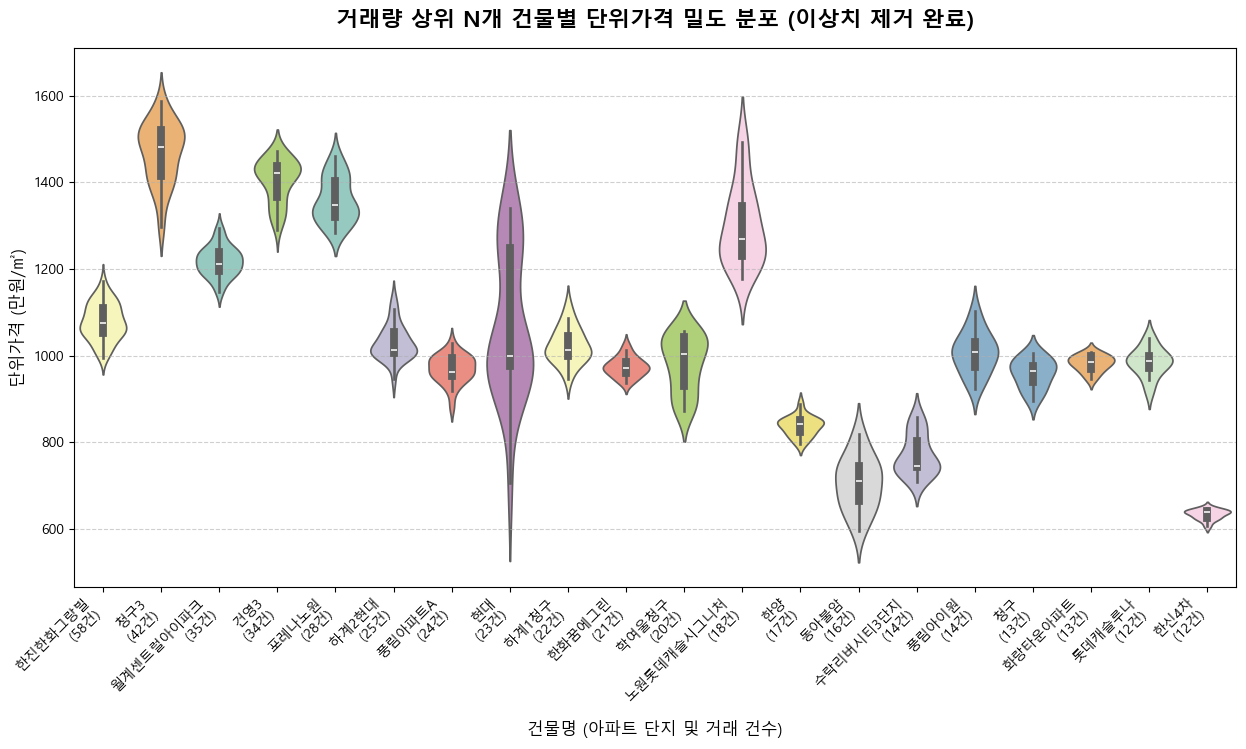

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이상치가 제거된 데이터에서 상위 N개 건물명과 각각의 거래 건수 집계
topN_counts = df_filtered_outliers['건물명'].value_counts().head(N)
topN_buildings = topN_counts.index

# 상위 N개 건물에 해당하는 데이터만 필터링
df_topN = df_filtered_outliers[df_filtered_outliers['건물명'].isin(topN_buildings)]

# 2. x축에 표시할 새 레이블 생성 (예: 건물명\n(000건))
# 텍스트가 겹치지 않도록 줄바꿈(\n)을 활용합니다.
new_x_labels = [f"{name}\n({topN_counts[name]}건)" for name in topN_buildings]

# 3. 바이올린 플롯 시각화
plt.figure(figsize=(15, 7))
sns.violinplot(
    data=df_topN, 
    x='건물명', 
    y='단위가격', 
    order=topN_buildings,  # 집계한 순서(거래량 순)대로 x축 정렬 고정
    hue='건물명', 
    palette='Set3', 
    legend=False
)

# 그래프 장식 및 레이블 설정
plt.title('거래량 상위 N개 건물별 단위가격 밀도 분포 (이상치 제거 완료)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('건물명 (아파트 단지 및 거래 건수)', fontsize=12)
plt.ylabel('단위가격 (만원/㎡)', fontsize=12)

# 중요: 기존 x축 텍스트를 거래 건수가 포함된 새 레이블로 교체
plt.xticks(ticks=range(N), labels=new_x_labels, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 파일 저장 및 출력
# plt.savefig('building_unit_price_violinplot_with_counts.png', bbox_inches='tight')
plt.show()

In [13]:
# 건물명별로 필요한 통계 함수를 지정하여 집계
summary_agg = df_topN.groupby('건물명')['단위가격'].agg(
    평균가격='mean',
    표준편차='std',
).round(2)  # 소수점 둘째 자리까지 반올림

# 평균가격이 높은 순서대로 정렬하여 출력
summary_agg_sorted = summary_agg.sort_values(by='평균가격', ascending=False)
summary_agg_sorted

,평균가격,표준편차
건물명,,
청구3,1468.33,70.96
건영3,1404.91,50.21
포레나노원,1359.76,52.28
노원롯데캐슬시그니처,1301.13,92.48
월계센트럴아이파크,1218.19,34.66
한진한화그랑빌,1078.37,42.55
현대,1070.27,168.34
하계2현대,1030.24,40.20
하계1청구,1023.91,41.36


#### 가설 설정

* **귀무가설 ($H_0$):** "10개 아파트 단지의 평균 단위가격은 모두 같다. (단지별 가격 차이가 없다.)"
* **대립가설 ($H_1$):** "10개 아파트 단지 중 적어도 한 단지의 평균 단위가격은 나머지 단지들과 다르다. (단지별 가격 차이가 존재한다.)"

3개 이상의 집단 간 평균 차이를 검정할 때는 SciPy 라이브러리의 `f_oneway`를 사용합니다. 일원배치 분산분석(One-way ANOVA)을 수행.

In [14]:
import scipy.stats as stats

# 1. 검정 대상인 상위 N개 건물 데이터만 필터링
target_buildings = list(summary_agg_sorted.index)
print(target_buildings)
print()

# 2. 각 건물별 단위가격 데이터를 리스트 형태로 분리하여 수집
group_data = [
    df_filtered_outliers[df_topN['건물명'] == building]['단위가격'] 
    for building in target_buildings
]

# 3. 일원배치 분산분석(One-way ANOVA) 수행
f_statistic, p_value = stats.f_oneway(*group_data)

print("--- 일원배치 분산분석(ANOVA) 결과 ---")
print(f"F-통계량 (F-statistic) : {f_statistic:.4f}")
print(f"유의확률 (p-value)      : {p_value}")

# 4. 결론 도출 (일반적인 유의수준 0.05 기준)
alpha = 0.05
if p_value < alpha:
    print("\n결론: 유의확률이 0.05보다 작으므로 귀무가설을 기각합니다.")
    print("즉, '건물명'별 아파트 단위가격의 차이는 통계적으로 명확하게 유의미합니다.")
else:
    print("\n결론: 귀무가설을 기각할 수 없습니다. 단지별 가격 차이가 우연일 가능성이 있습니다.")

['청구3', '건영3', '포레나노원', '노원롯데캐슬시그니처', '월계센트럴아이파크', '한진한화그랑빌', '현대', '하계2현대', '하계1청구', '풍림아이원', '롯데캐슬루나', '화랑타운아파트', '학여울청구', '한화꿈에그린', '풍림아파트A', '청구', '한양', '수락리버시티3단지', '동아불암', '한신4차']

--- 일원배치 분산분석(ANOVA) 결과 ---
F-통계량 (F-statistic) : 311.2309
유의확률 (p-value)      : 1.504938609564075e-241

결론: 유의확률이 0.05보다 작으므로 귀무가설을 기각합니다.
즉, '건물명'별 아파트 단위가격의 차이는 통계적으로 명확하게 유의미합니다.


### 건축년도와 법정동명이 가격에 영향을 미쳤을까?

건물명(단지명)을 기준으로 법정동명과 건축년도, 단위가격에 대한 평균, 표준편차를 정리

In [15]:
import pandas as pd

# '건물명'을 기준으로 그룹화하여 필요한 지표들을 산출합니다.
# 법정동명과 건축년도는 건물별로 동일하므로 'first'(첫 번째 값)를 지정하여 가져옵니다.
building_summary = df_topN.groupby('건물명').agg(
    법정동명=('법정동명', 'first'),
    건축년도=('건축년도', 'first'),
    금액_평균=('단위가격', 'mean'),
    금액_표준편차=('단위가격', 'std')
).reset_index()

# 보기 편하게 금액 평균을 기준으로 내림차순 정렬하고 소수점 첫째 자리까지 정리합니다.
building_summary = building_summary.sort_values(by='금액_평균', ascending=False)
building_summary[['금액_평균', '금액_표준편차']] = building_summary[['금액_평균', '금액_표준편차']].round(1)

# 결과 출력
building_summary

,건물명,법정동명,건축년도,금액_평균,금액_표준편차
7,청구3,중계동,1996.0,1468.3,71.0
0,건영3,중계동,1995.0,1404.9,50.2
8,포레나노원,상계동,2020.0,1359.8,52.3
1,노원롯데캐슬시그니처,상계동,2023.0,1301.1,92.5
5,월계센트럴아이파크,월계동,2020.0,1218.2,34.7
16,한진한화그랑빌,월계동,2002.0,1078.4,42.5
18,현대,하계동,1988.0,1070.3,168.3
12,하계2현대,하계동,1997.0,1030.2,40.2
11,하계1청구,하계동,1997.0,1023.9,41.4
9,풍림아이원,월계동,2005.0,1007.5,49.0


### 건축년도와 금액_평균의 산포도

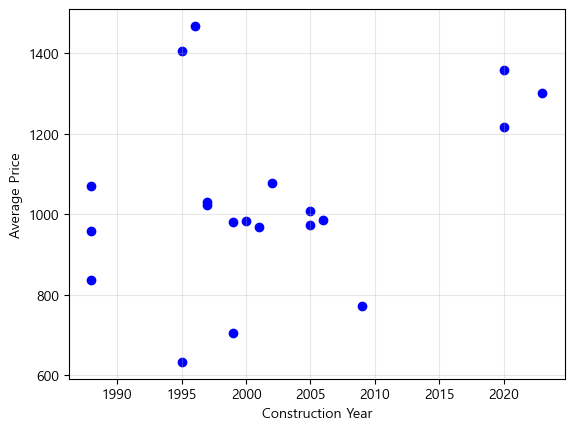

In [16]:
import matplotlib.pyplot as plt

plt.scatter(building_summary['건축년도'], building_summary['금액_평균'], color='blue')
plt.xlabel('Construction Year')
plt.ylabel('Average Price')
plt.grid(True, alpha=0.3)
plt.show()

### 상관계수 분석

In [17]:
import scipy.stats as stats

# 1. 피어슨 상관분석 수행
# 두 연속형 변수(건축년도, 금액_평균) 간의 상관계수와 p-value를 계산합니다.
correlation, p_value = stats.pearsonr(building_summary['건축년도'], building_summary['금액_평균'])

print("--- 상관관계 분석 결과 ---")
print(f"* 피어슨 상관계수 (r): {correlation:.4f}")
print(f"* 유의확률 (p-value) : {p_value:.4e}")

# 2. 통계적 유의성 판단 (유의수준 0.05 기준)
print("\n--- 결과 해석 ---")
if p_value < 0.05:
    print("p-value가 0.05보다 작으므로 두 변수 간에는 통계적으로 유의미한 상관관계가 있습니다.")
    if correlation > 0:
        print("양(+)의 상관관계가 나타나며, 이는 건축년도가 최신일수록(지어진 지 얼마 안 되었을수록) 금액 평균이 높은 경향이 있음을 뜻합니다.")
    else:
        print("음(-)의 상관관계가 나타나며, 이는 건축년도가 오래되었을수록 금액 평균이 높은 경향이 있음을 뜻합니다.")
else:
    print("p-value가 0.05보다 크므로 두 변수 간의 상관관계는 통계적으로 유의미하지 않습니다.")
    print("즉, 건축년도와 금액 평균 사이에 뚜렷한 선형적 관계가 있다고 보기 어렵습니다.")

--- 상관관계 분석 결과 ---
* 피어슨 상관계수 (r): 0.3448
* 유의확률 (p-value) : 1.3655e-01

--- 결과 해석 ---
p-value가 0.05보다 크므로 두 변수 간의 상관관계는 통계적으로 유의미하지 않습니다.
즉, 건축년도와 금액 평균 사이에 뚜렷한 선형적 관계가 있다고 보기 어렵습니다.


### 법정동명과 가격의 차이(ANOVA 분석)

In [18]:
import scipy.stats as stats

# 1. 법정동명별로 '금액_평균' 데이터를 그룹화하여 리스트로 분리합니다.
groups = [group['금액_평균'].values for name, group in building_summary.groupby('법정동명')]

# 2. 일원분산분석(One-way ANOVA) 수행
f_stat, p_value = stats.f_oneway(*groups)

print("--- 집단 간 차이 분석 결과 (ANOVA) ---")
print(f"* F-통계량 (F-statistic): {f_stat:.4f}")
print(f"* 유의확률 (p-value)    : {p_value:.4f}")

# 3. 통계적 유의성 판단 (유의수준 0.05 기준)
print("\n--- 결과 해석 ---")
if p_value < 0.05:
    print("p-value가 0.05보다 작으므로 법정동명에 따른 금액_평균의 차이는 통계적으로 유의미합니다.")
    print("즉, 어느 동에 위치하느냐에 따라 건물들의 평균 금액이 다르다고 볼 수 있습니다.")
else:
    print("p-value가 0.05보다 크므로 법정동명에 따른 금액_평균의 차이는 통계적으로 유의미하지 않습니다.")
    print("즉, 동별 금액_평균의 차이가 대동소이하거나 단순한 우연에 의한 차이일 가능성이 높습니다.")

--- 집단 간 차이 분석 결과 (ANOVA) ---
* F-통계량 (F-statistic): 1.4285
* 유의확률 (p-value)    : 0.2727

--- 결과 해석 ---
p-value가 0.05보다 크므로 법정동명에 따른 금액_평균의 차이는 통계적으로 유의미하지 않습니다.
즉, 동별 금액_평균의 차이가 대동소이하거나 단순한 우연에 의한 차이일 가능성이 높습니다.
